In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp

In [51]:
salary = pd.read_csv("Salary.csv")

In [53]:
msk = salary[salary['Регион'] == 'Москва'].dropna()

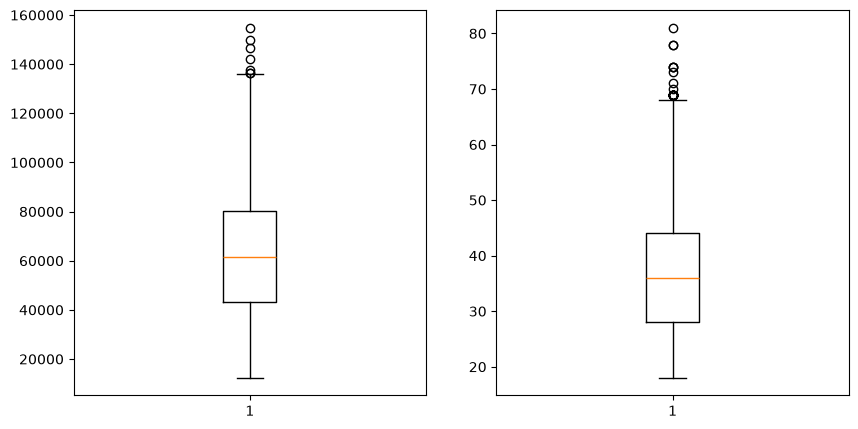

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(msk['Зарплата'])
axes[1].boxplot(msk['Возраст'])
plt.show()

In [55]:
cols = ['Зарплата', 'Возраст']

mask = pd.Series(True, index=msk.index)

for col in cols:
    lower = msk[col].mean() - 3 * msk[col].std()
    upper = msk[col].mean() + 3 * msk[col].std()

    mask &= msk[col].between(lower, upper)

msk_clean = msk.loc[mask].copy()

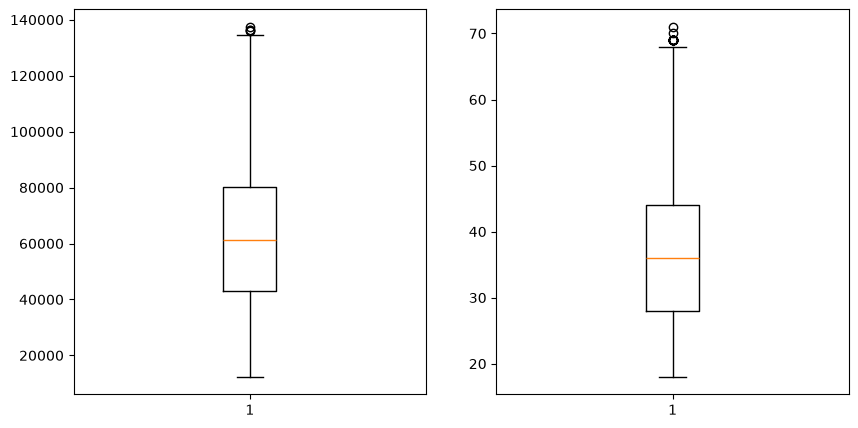

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(msk_clean['Зарплата'])
axes[1].boxplot(msk_clean['Возраст'])
plt.show()

<Axes: xlabel='Возраст', ylabel='Зарплата'>

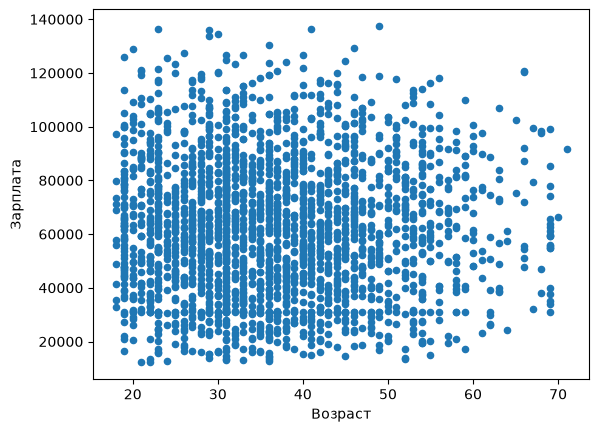

In [57]:
msk_clean.plot.scatter(x='Возраст', y ='Зарплата')

In [59]:
msk_clean[cols].corr()

,Зарплата,Возраст
Зарплата,1.000000,0.005569
Возраст,0.005569,1.000000


In [60]:
msk[cols].corr()

,Зарплата,Возраст
Зарплата,1.000000,0.010798
Возраст,0.010798,1.000000


In [62]:
stats.pearsonr(msk_clean[cols[0]], msk_clean[cols[1]])

PearsonRResult(statistic=np.float64(0.005569392923210602), pvalue=np.float64(0.7886108042281964))

### Independence PSES p-393

Suppose that we wish to determine whether the opinions of the voting residents of the state of Illinois concerning a new tax reform are independent of their levels of income. 

Members of a random sample of 1000 registered voters from the state of Illinois are classified as to whether they are in a low, medium, or high income bracket and whether or not they favor the tax reform. 

The observed frequencies are presented in Table 10.6, which is known as a contingency table.

A contingency table with r rows and c columns is referred to as an r × c table (“r × c” is read “r by c”). 

The row and column totals in Table 10.6 are called marginal frequencies. 

Our decision to accept or reject the null hypothesis, H0, of independence between a voter’s opinion concerning the tax reform and his or her level of income is based upon how good a fit we have between the observed frequencies in each of the 6 cells of Table 10.6 and the frequencies that we would expect for each cell under the assumption that H0 is true.

In [ ]:
# p-395 voters for/against tax reform

f_obs = pd.array([182, 213, 203, 154, 138, 110])
f_exp = pd.array([200.9, 209.9, 187.2, 135.1, 141.1, 125.8])

# “Delta degrees of freedom”: adjustment to the degrees of freedom for the p-value. 
# The p-value is computed using a chi-squared distribution with k - 1 - ddof degrees of freedom, 
# where k is the number of categories. 
# The default value of ddof is 0.

# Here num of rows r = 2, cols c = 3, df = (r - 1)*(c - 1) => since k = 6 we need final df be equal to 2. 
# So df = 2 = k - 1 - x gives x = 3 for k = 6.

stats.chisquare(f_obs=f_obs, f_exp=f_exp, ddof=3)

Power_divergenceResult(statistic=np.float64(7.853948385188133), pvalue=np.float64(0.01970320053764698))

In [ ]:
f_obs = np.array([[182, 213, 203],
                  [154, 138, 110]])

column_marginal_frequencies = f_obs.sum(axis=0)
row_marginal_frequencies = f_obs.sum(axis=1)
grand_total = f_obs.sum()

f_exp = np.outer(row_marginal_frequencies, column_marginal_frequencies) / grand_total

df = (len(row_marginal_frequencies) - 1) * (len(column_marginal_frequencies) - 1)
ddof = f_obs.size - 1 - df
 
print(f_obs)
print(f_exp)
print(stats.chisquare(f_obs=f_obs.flatten(), f_exp=f_exp.flatten(), ddof=ddof))



[[182 213 203]
 [154 138 110]]
[[200.928 209.898 187.174]
 [135.072 141.102 125.826]]
Power_divergenceResult(statistic=np.float64(7.878211595034106), pvalue=np.float64(0.019465613164995295))


In [30]:
print(stats.chi2_contingency(f_obs))

Chi2ContingencyResult(statistic=np.float64(7.878211595034106), pvalue=np.float64(0.019465613164995295), dof=2, expected_freq=array([[200.928, 209.898, 187.174],
       [135.072, 141.102, 125.826]]))


- Данные нормальные -> Корреляция Пирсона scipy.stats.pearsonr(x, y, alternative='two-sided')
 
- Данные ненормальные или порядковые -> Корреляция Спирмена scipy.stats.spearmanr(a, b=None, alternative='two-sided')
 
- Данные ненормальные / с выбросами или порядковые -> Корреляция Кендалла scipy.stats.kendalltau(x, y, alternative='two-sided')
 
- Данные бинарные -> Коэффициент φ 
 
- Данные бинарные и численные -> Точечная двухрядная корреляция 

1